# Diplomatura en Python para la Ciencia de Datos y Machine Learning
## Trabajo Práctico 3: Perceptrón Multicapa (MLP)

**Tema:** Perceptrón Multicapa y Redes Neuronales Artificiales sobre MNIST.

### Pasos generales en la implementación de una Red Neuronal Artificial:
a. Importar las librerías necesarias.
b. Definir el conjunto de datos de entrenamiento: vectores de entrada y salida.
c. Definir la arquitectura de la Red Neuronal Artificial.
d. Configurar el proceso de aprendizaje mediante la selección de una función de error, una función de optimización y métricas de monitoreo.
e. Entrenar la RNA con el conjunto de entrenamiento mediante el método `fit()`.
f. Predecir y evaluar el modelo.
g. Guardar el modelo.

### 1. Carga del Conjunto de Datos y Exploración Inicial

**Ejercicio 1 y 2:** 
1. Importa las librerías necesarias y el conjunto de datos MNIST, guardándolo en las variables `X_train`, `y_train`, `X_test`, `y_test`.
2. Explora la forma (`shape`) de los datos y accede al primer elemento de cada conjunto.

In [1]:
# Ejercicio 1: Importar librerias necesarias y el conjunto de datos mnist
import numpy as np
from tensorflow.keras.datasets import mnist

# Cargar el conjunto de datos en X_train, y_train, X_test, y_test
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Ejercicio 2: Explorar las formas (shape) de los conjuntos de datos
print("Forma de X_train:", X_train.shape)   # (60000, 28, 28) -> 60000 imagenes de 28x28 pixeles
print("Forma de y_train:", y_train.shape)   # (60000,)        -> 60000 etiquetas (0 al 9)
print("Forma de X_test :", X_test.shape)    # (10000, 28, 28)
print("Forma de y_test :", y_test.shape)    # (10000,)
print("Valor minimo y maximo de los pixeles:", X_train.min(), "-", X_train.max())

# Acceder e imprimir el primer elemento de cada conjunto
print()
print("Primer elemento de X_train (matriz 28x28 con la intensidad de cada pixel):")
print(X_train[0])
print()
print("Primer elemento de y_train (etiqueta):", y_train[0])
print("Primer elemento de X_test -> forma:", X_test[0].shape)
print("Primer elemento de y_test (etiqueta):", y_test[0])

Forma de X_train: (60000, 28, 28)
Forma de y_train: (60000,)
Forma de X_test : (10000, 28, 28)
Forma de y_test : (10000,)
Valor minimo y maximo de los pixeles: 0 - 255

Primer elemento de X_train (matriz 28x28 con la intensidad de cada pixel):
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 

### 2. Visualización de Muestras

**Ejercicio 3:** Visualiza algunos elementos del conjunto de datos con `matplotlib`.

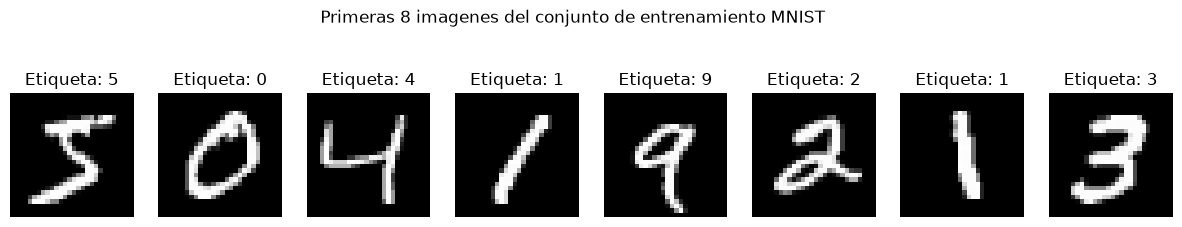

In [2]:
import matplotlib.pyplot as plt

# Ejercicio 3: Visualizar algunos elementos del conjunto de entrenamiento
plt.figure(figsize=(15, 3))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Etiqueta: {y_train[i]}")
    plt.axis('off')
plt.suptitle("Primeras 8 imagenes del conjunto de entrenamiento MNIST")
plt.show()

### 3. Preprocesamiento: Normalización y Aplanado (Reshape)

**Ejercicio 5:** Normaliza los conjuntos de datos dividiendo entre 255.
$$\text{X\_train} = \frac{\text{X\_train}}{255}, \quad \text{X\_test} = \frac{\text{X\_test}}{255}$$

**Ejercicio 6:** Aplanar las imágenes. El Perceptrón no trabaja con imágenes crudas 2D ($28 \times 28$). Necesita que cada imagen esté aplanada en un vector de características de 784 elementos.

In [3]:
# Ejercicio 5: Normalizar los datos dividiendo por 255.0
# Los pixeles pasan del rango [0, 255] al rango [0, 1]
X_train = X_train / 255.0
X_test  = X_test / 255.0

# Ejercicio 6: Aplanar las imagenes a vectores de 784 caracteristicas usando .reshape()
X_train = X_train.reshape(len(X_train), -1)
X_test  = X_test.reshape(len(X_test), -1)

# Imprimir las nuevas formas de X_train y X_test
print("Forma de X_train luego del reshape:", X_train.shape)   # (60000, 784)
print("Forma de X_test  luego del reshape:", X_test.shape)    # (10000, 784)
print("Nuevo rango de valores:", X_train.min(), "-", X_train.max())

Forma de X_train luego del reshape: (60000, 784)
Forma de X_test  luego del reshape: (10000, 784)
Nuevo rango de valores: 0.0 - 1.0


### 4. Definición y Entrenamiento del Modelo Perceptrón Multicapa (MLP)

**Ejercicio 7:** Definir el modelo `MLPClassifier` de `sklearn.neural_network` y entrenarlo con el comando `.fit()`.
El modelo debe tener:
- Una capa oculta de 50 neuronas (`hidden_layer_sizes=(50,)`)
- Función de activación `'logistic'`
- Optimizador `'sgd'` (Descenso de Gradiente Estocástico)

In [4]:
from sklearn.neural_network import MLPClassifier

# Ejercicio 7: Definir el modelo MLPClassifier con los parametros especificados
modelo = MLPClassifier(hidden_layer_sizes=(50,), activation='logistic', solver='sgd', max_iter=200, random_state=42)

# Entrenar el modelo con los datos aplanados y normalizados
modelo.fit(X_train, y_train)

print("Entrenamiento finalizado.")
print("Iteraciones realizadas:", modelo.n_iter_)
print("Perdida final (Cross-Entropy):", modelo.loss_)

Entrenamiento finalizado.
Iteraciones realizadas: 200
Perdida final (Cross-Entropy): 0.2228156103097636


C:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


### 5. Inspección de Parámetros de la Red

**Ejercicio 8:** Observa e inspecciona los parámetros de las capas usando los atributos del modelo:
- `modelo.n_layers_`
- `modelo.n_outputs_`
- `modelo.coefs_[0].shape` y `modelo.coefs_[1].shape`

In [5]:
# Ejercicio 8: Imprimir la cantidad de capas, salidas y formas de las matrices de pesos coefs_
print("Numero de capas:", modelo.n_layers_)                                      # 3 = entrada + oculta + salida
print("Numero de salidas:", modelo.n_outputs_)                                   # 10 = digitos del 0 al 9
print("Forma de pesos entre entrada y capa oculta:", modelo.coefs_[0].shape)     # (784, 50)
print("Forma de pesos entre capa oculta y salida:", modelo.coefs_[1].shape)      # (50, 10)
print("Forma de los bias de la capa oculta:", modelo.intercepts_[0].shape)       # (50,)
print("Forma de los bias de la capa de salida:", modelo.intercepts_[1].shape)    # (10,)

# Cantidad total de parametros entrenables de la red
total = sum(w.size for w in modelo.coefs_) + sum(b.size for b in modelo.intercepts_)
print("Total de parametros entrenables:", total)

Numero de capas: 3
Numero de salidas: 10
Forma de pesos entre entrada y capa oculta: (784, 50)
Forma de pesos entre capa oculta y salida: (50, 10)
Forma de los bias de la capa oculta: (50,)
Forma de los bias de la capa de salida: (10,)
Total de parametros entrenables: 39760


### 6. Predicción y Evaluación

**Ejercicio 9:** Realizar la predicción con el conjunto de datos de prueba `X_test`.

**Ejercicio 10:** Evaluar el modelo calculando el $F_1$-score promedio ponderado (`average="weighted"`).

In [6]:
from sklearn.metrics import f1_score

# Ejercicio 9: Realizar las predicciones sobre el conjunto de prueba X_test
y_pred = modelo.predict(X_test)
print("Primeras 10 predicciones   :", y_pred[:10])
print("Primeras 10 etiquetas reales:", y_test[:10])

# Ejercicio 10: Calcular y mostrar el f1_score ponderado
f1 = f1_score(y_test, y_pred, average="weighted")
print()
print(f"F1-score (weighted): {f1:.4f}")

Primeras 10 predicciones   : [7 2 1 0 4 1 4 9 6 9]
Primeras 10 etiquetas reales: [7 2 1 0 4 1 4 9 5 9]

F1-score (weighted): 0.9359


### 7. Guardar el Modelo en Disco

**Ejercicio 11:** Guardar el modelo entrenado en disco para su posterior reutilización utilizando la librería `joblib`.

In [7]:
import joblib

# Ejercicio 11: Guardar el modelo entrenado en disco
joblib.dump(modelo, 'modelo_mnist.pkl')
print("Modelo guardado como 'modelo_mnist.pkl'")

# Comprobacion: volver a cargarlo desde disco y predecir con el modelo recuperado
modelo_cargado = joblib.load('modelo_mnist.pkl')
print("Prediccion del modelo recargado para la primera imagen de test:",
      modelo_cargado.predict(X_test[:1])[0], "| Etiqueta real:", y_test[0])

Modelo guardado como 'modelo_mnist.pkl'
Prediccion del modelo recargado para la primera imagen de test: 7 | Etiqueta real: 7
